# TEST CAA - QUANTITATIVE RESEARCHER ROLE

The traditional way of building an investment portfolio is a two-step process that separates parameter estimation from optimization: 
- First, expected returns and dependence relationships (covariances) between assets are estimated.
- Second, these estimates are plugged into a mathematical model, to find the optimal mix of assets accordingly to the objective. 

The main issue with this “estimate-then-optimize” approach is that both steps are treated as separate tasks, leading to several issues, in particular with multivariate time series data: 
- First, estimation errors get magnified during the optimization process. 
- Second, the method focuses on the wrong goal – creating the best statistical model, rather than finding the parameters that will lead to the best decision in the future. 
- Third, it gets trickier as dimensions (e.g. portfolio assets) increase. Accurately estimating how hundreds or thousands of assets will interact with each other (a high-dimensional problem) is incredibly difficult and statistically fragile. State-of-the-art methods require a huge amount of effort to get this estimation right, which remains a major hurdle.

Machine Learning applies in portfolio management in two main ways. 
- The first approach involves forecasting, where models predict stock movements to inform a rule-based system. 
- The second approach uses Reinforcement Learning (RL), where an agent directly learns to execute actions (buy, sell, hold) by optimizing for long-term rewards, making it ideal for scenarios where the final outcome is only known at the end of a trading period.

**This notebook objective is to develop of policy (strategy) for building a portfolio. The portfolio is essentially an allocation of available resources across various assets. The policy then needs to restructure the portfolio over time as new information becomes available.**

In simple terms: **Given histories of 3 different assets (equities, bonds and gold), how would you allocate a fixed amount of money between these stocks every day that maximize the likelihood of returns.**

**Your role**: Develop a reinforcement learning model — an agent that allocates stocks at every time step by observing the indicators for each stock. In more details, your goal is to design an agent that interacts with a trading environment to maximize portfolio value. In this setup, each day should represent the agent's decision on asset allocation (e.g., 30% equities, 30% bonds, 30% gold). Based on the performance of this allocation, the agent receives a positive or negative reward. Through iterative learning, the agent refines its strategy to identify the optimal asset allocation for any given market state. Ultimately, you can compare your RL policy with Markowitz’ efficient frontier approach as natural benchmark. Cherry on the cake : include transaction costs - 2 bps for bonds, 5 bps for stocks and 10 bps for gold (1 bp = 0.01%)

**Rules**: 
- From PPO to DPO, choose the RL approach that suits best accordingly to the objective from your point of view.
- Please defend and motivate your choices.
- Be short and clear

**Data**: Attached dataset contains the daily returns from 4th of January, 1999 until 30th of September, 2025, for 3 assets 
- Equities (MSCI World Index, MXWD Index)
- Gold (XAU Curncy)
- Fixed-Income (Bloomberg Global Aggregate TR Index)

Only the attached data must be used in the context of the exercice.

**Première Étape : PRE-PROCESSING DES DONNÉES**

In [17]:
"""
Quantitative Research Notebook — Reinforcement Learning for Strategic Asset Allocation
========================================================================================
Scope   : Train a PPO agent to dynamically allocate capital across Equities, Gold and
          Fixed-Income, net of asset-specific transaction costs, and benchmark it
          against a classical Markowitz mean-variance efficient frontier.

This cell wires up the research environment: reproducibility, structured logging,
a consistent plotting theme, and the scientific-computing / RL stack used throughout.
"""

from __future__ import annotations

import json
import logging
import random
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --------------------------------------------------------------------------- #
# Reproducibility — a single seed propagated to numpy, random and the RL stack
# --------------------------------------------------------------------------- #
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)

# --------------------------------------------------------------------------- #
# Logging — structured logs beat scattered print() statements in a research
# pipeline that will eventually be re-run, reviewed and reproduced by others.
# --------------------------------------------------------------------------- #
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(message)s",
    datefmt="%H:%M:%S",
    force=True,
)
logger = logging.getLogger("quant_rl")

# --------------------------------------------------------------------------- #
# Plotting theme
# --------------------------------------------------------------------------- #
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})

# --------------------------------------------------------------------------- #
# Paths
# --------------------------------------------------------------------------- #
DATA_PATH = Path("RL_toy_data.xlsx")
OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

logger.info("Environment initialised (seed=%d).", SEED)

22:46:47 | INFO    | Environment initialised (seed=42).


In [18]:
@dataclass(frozen=True)
class AssetConfig:
    """Business-defined parameters of the investable universe."""

    names: Tuple[str, str, str] = ("Equities", "Gold", "Fixed-Income")
    # One-way, proportional transaction costs, in basis points (1 bp = 0.01% = 1e-4)
    transaction_costs_bps: Dict[str, float] = field(
        default_factory=lambda: {"Equities": 5.0, "Gold": 10.0, "Fixed-Income": 2.0}
    )

    @property
    def transaction_costs(self) -> Dict[str, float]:
        """Costs expressed as decimals, keyed by asset name."""
        return {asset: bps / 1e4 for asset, bps in self.transaction_costs_bps.items()}


@dataclass
class ExperimentConfig:
    """
    Single source of truth for every tunable parameter of the study. Centralising
    configuration here — rather than scattering magic numbers through the notebook —
    makes the experiment auditable and trivially reproducible.
    """

    # --- Capital & environment ------------------------------------------------
    initial_capital: float = 10_000.0
    lookback_window: int = 10          # days of return history embedded in the state
    trading_days_per_year: int = 252
    train_fraction: float = 0.80       # chronological train / test split

    # --- PPO hyperparameters ----------------------------------------------------
    learning_rate: float = 3e-4
    n_steps: int = 256
    batch_size: int = 64
    n_epochs_over_dataset: int = 10    # full replays of the training window
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_range: float = 0.2
    ent_coef: float = 0.0
    net_arch: Tuple[int, ...] = (64, 64)   # shallow MLP — see rationale above

    seed: int = SEED
    assets: AssetConfig = field(default_factory=AssetConfig)


CFG = ExperimentConfig()
logger.info(
    "Experiment configuration:\n%s",
    json.dumps({k: v for k, v in vars(CFG).items() if k != "assets"}, indent=2, default=str),
)

22:46:47 | INFO    | Experiment configuration:
{
  "initial_capital": 10000.0,
  "lookback_window": 10,
  "trading_days_per_year": 252,
  "train_fraction": 0.8,
  "learning_rate": 0.0003,
  "n_steps": 256,
  "batch_size": 64,
  "n_epochs_over_dataset": 10,
  "gamma": 0.99,
  "gae_lambda": 0.95,
  "clip_range": 0.2,
  "ent_coef": 0.0,
  "net_arch": [
    64,
    64
  ],
  "seed": 42
}


In [19]:
def load_returns(path: Path) -> pd.DataFrame:
    """
    Load and validate the daily total-return series used throughout the study.

    Parameters
    ----------
    path : Path to the source spreadsheet (dates as index, one column per asset).

    Returns
    -------
    pd.DataFrame, float32, sorted chronologically, guaranteed free of missing values.
    """
    raw = pd.read_excel(path, index_col=0, parse_dates=True)

    rename_map = {
        "Equities (MXWD Index)": "Equities",
        "Gold (XAU Curncy)": "Gold",
        "Fixed-Income (LEGATRUU Index)": "Fixed-Income",
    }
    frame = raw.rename(columns=rename_map).astype(np.float32).sort_index()

    # --- Data quality gate ---------------------------------------------------
    assert not frame.isna().any().any(), "Missing values detected in the return series."
    assert frame.index.is_monotonic_increasing, "Dates are not sorted chronologically."
    assert not frame.index.duplicated().any(), "Duplicate dates detected."
    assert list(frame.columns) == list(CFG.assets.names), f"Unexpected column set: {list(frame.columns)}"

    logger.info(
        "Loaded %d observations spanning %s -> %s across %d assets.",
        len(frame), frame.index.min().date(), frame.index.max().date(), frame.shape[1],
    )
    return frame


df = load_returns(DATA_PATH)
df.head()

22:46:48 | INFO    | Loaded 6977 observations spanning 1999-01-04 -> 2025-09-30 across 3 assets.


,Equities,Gold,Fixed-Income
Date,,,
1999-01-04,0.0103,-0.0002,0.0000
1999-01-05,0.0102,-0.0026,-0.0013
1999-01-06,0.0190,0.0047,-0.0013
1999-01-07,-0.0027,0.0106,-0.0010
1999-01-08,-0.0010,0.0000,-0.0061


In [20]:
def data_quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    """Compact per-asset sanity report: dtype, coverage, and basic range checks."""
    return pd.DataFrame(
        {
            "dtype": frame.dtypes.astype(str),
            "n_obs": frame.count(),
            "n_missing": frame.isna().sum(),
            "min_return": frame.min(),
            "max_return": frame.max(),
        }
    )


data_quality_report(df)

,dtype,n_obs,n_missing,min_return,max_return
Equities,float32,6977,0,-0.0951,0.0931
Gold,float32,6977,0,-0.0907,0.1079
Fixed-Income,float32,6977,0,-0.0218,0.0286


In [21]:
def annualized_stats(returns: pd.DataFrame, periods_per_year: int = CFG.trading_days_per_year) -> pd.DataFrame:
    """
    Buy-and-hold risk/return statistics, annualised — the natural first exhibit of
    any return-series exploration, and the benchmark against which any active
    strategy (rule-based or learned) must eventually be judged.
    """
    ann_return = returns.mean() * periods_per_year
    ann_vol = returns.std(ddof=0) * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol
    nav = (1 + returns).cumprod()
    max_dd = (nav / nav.cummax() - 1).min()

    return pd.DataFrame(
        {
            "Ann. Return": ann_return,
            "Ann. Volatility": ann_vol,
            "Sharpe (rf=0)": sharpe,
            "Skewness": returns.skew(),
            "Max Drawdown": max_dd,
        }
    )


summary = annualized_stats(df)
print(summary.round(4).to_string())

              Ann. Return  Ann. Volatility  Sharpe (rf=0)  Skewness  Max Drawdown
Equities           0.0584           0.1553         0.3760   -0.4076       -0.5961
Gold               0.1076           0.1664         0.6467    0.0080       -0.4468
Fixed-Income       0.0301           0.0535         0.5622    0.1094       -0.2567


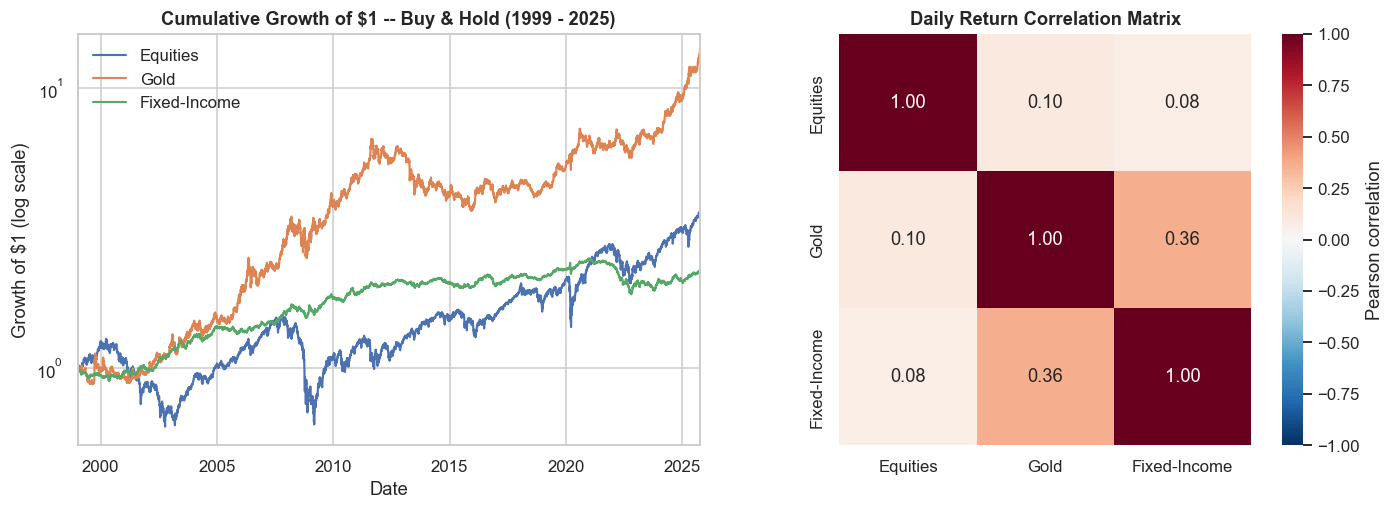

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

cum_growth = (1 + df).cumprod()
cum_growth.plot(ax=axes[0], linewidth=1.4)
axes[0].set_title("Cumulative Growth of $1 -- Buy & Hold (1999 - 2025)")
axes[0].set_ylabel("Growth of $1 (log scale)")
axes[0].set_yscale("log")
axes[0].legend(title=None, frameon=False)

corr = df.corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0.0, vmin=-1, vmax=1,
    square=True, cbar_kws={"label": "Pearson correlation"}, ax=axes[1],
)
axes[1].set_title("Daily Return Correlation Matrix")

plt.tight_layout()
plt.show()

L'excel donné comporte donc les rendements, par rapport au jour précédent, de chaque actif. (Petite remarque mais l'or est, en moyenne, presque 2 fois plus rentables que les equities sur les 25 dernières années mais aussi un peu plus volatil (std).. )

Il est nécessaire de conserver les valeurs en rendements car l'environnement n'utilise que la valeur du portefeuille (qu'on initialisera arbitrairement).

Tout d'abord, un peu de bibliographie s'impose. Je vais consulter des papiers de recherche sur le thème de l'asset allocation avec le Reinforcement Learning. Cette recherche sur **l'état de l'art va me permettre de choisir l'algorithme le plus adapté au problème** : un problème d'asset allocation avec coûts de transaction.

L'état de l'art se situe probablement dans l'algorithme **PPO (Proximal Policy Optimisation)** d'après [1]. En effet, l'utilisation de PPO en (interday) est pertinente car elle répond au besoin de stabilité de l'allocation d'actifs sur le long terme. L'espace d'action étant continu (les poids du portefeuille), PPO est plus adapté que des méthodes basées sur la valeur (comme DQN).
De plus, son **mécanisme de clipping [2] évitant un shift des poids trop rapide entre 2 jours consécutifs** permet d'éviter que la "policy" devienne instable lors de changements de régime de marchés (et ainsi évite des couts transactionnels trop importants!!).

Pour ce qui est de l'architecture de cet algorithme, conscient de la limitation du nombre de données en interday (~6500 points), il est plus importnant d'utiliser une architecture neuronale simple (MLP peu profond) pour éviter l'overfitting, contrairement aux modèles profonds (CNN/LSTM).

On va pouvoir utiliser la bibliothèque Stable Baselines3 pour implémenter tout cela.


Sources :
[1] Deep Reinforcement Learning for Active High Frequency Trading, Briola, 2021
[2] Proximal Policy Optimization Algorithms, Schulman, 2017

**Deuxième Étape : CRÉATION DE LA CLASSE NÉCESSAIRE AU MODÈLE**

In [23]:
class PortfolioAllocationEnv(gym.Env):
    """
    Continuous, long-only, fully-invested strategic asset allocation environment
    with proportional, asset-specific transaction costs.

    Markov Decision Process
    ------------------------
    State  s_t : the trailing `lookback_window` daily returns for every asset
                 (flattened, most recent last) concatenated with the portfolio
                 weights held entering day t.
                 dim(s_t) = n_assets * lookback_window + n_assets.

    Action a_t : raw scores in [0, 1]^n_assets. They are projected onto the
                 probability simplex inside `step`, so a standard bounded Box
                 action space is enough to represent a long-only, fully-invested
                 portfolio without a dedicated constrained-optimisation layer.

    Reward r_t : log(V_t / V_{t-1}) -- the daily log-return of the portfolio, net
                 of transaction costs. Log-returns are time-additive, which keeps
                 the cumulative reward numerically stable over multi-thousand-step
                 episodes and is the natural objective of a compounding investor.

    Costs      : linear in turnover, cost_t = costs . |w_t - w_{t-1}| . V_{t-1},
                 deducted from the mark-to-market portfolio value at each step.
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        returns: pd.DataFrame,
        initial_capital: float = 10_000.0,
        lookback_window: int = 10,
        transaction_costs: Optional[Dict[str, float]] = None,
    ) -> None:
        super().__init__()

        if returns.isna().any().any():
            raise ValueError("Return series passed to the environment contains NaNs.")

        self.asset_names: List[str] = list(returns.columns)
        self.n_assets: int = len(self.asset_names)
        self.dates: pd.DatetimeIndex = returns.index
        self._returns: np.ndarray = returns.to_numpy(dtype=np.float32)

        self.initial_capital = float(initial_capital)
        self.lookback_window = int(lookback_window)
        if len(self._returns) <= self.lookback_window + 1:
            raise ValueError("Return series too short for the requested lookback window.")

        costs = transaction_costs or {}
        self.transaction_costs = np.array(
            [costs.get(a, 0.0) for a in self.asset_names], dtype=np.float32
        )

        # --- Gymnasium spaces --------------------------------------------------
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(self.n_assets,), dtype=np.float32)
        obs_dim = self.n_assets * self.lookback_window + self.n_assets
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)

        # --- Episode state (populated in reset) ---------------------------------
        self.current_step: int = self.lookback_window
        self.portfolio_value: float = self.initial_capital
        self.weights: np.ndarray = np.full(self.n_assets, 1.0 / self.n_assets, dtype=np.float32)
        self.value_history: List[float] = []
        self.weight_history: List[np.ndarray] = []
        self.cost_history: List[float] = []

    # -------------------------------------------------------------------------- #
    def _get_observation(self) -> np.ndarray:
        window = self._returns[self.current_step - self.lookback_window : self.current_step]
        return np.concatenate([window.flatten(), self.weights]).astype(np.float32)

    @staticmethod
    def _project_to_simplex(raw_action: np.ndarray, fallback: np.ndarray) -> np.ndarray:
        """Clip to [0, 1], then renormalise onto the fully-invested simplex."""
        clipped = np.clip(raw_action, 0.0, 1.0)
        total = clipped.sum()
        if total < 1e-8:
            return fallback.copy()
        return clipped / total

    # -------------------------------------------------------------------------- #
    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)

        self.current_step = self.lookback_window
        self.portfolio_value = self.initial_capital
        self.weights = np.full(self.n_assets, 1.0 / self.n_assets, dtype=np.float32)

        self.value_history = [self.portfolio_value]
        self.weight_history = [self.weights.copy()]
        self.cost_history = [0.0]

        return self._get_observation(), {"portfolio_value": self.portfolio_value}

    def step(self, action: np.ndarray):
        target_weights = self._project_to_simplex(np.asarray(action, dtype=np.float32), self.weights)

        turnover = np.abs(target_weights - self.weights)
        cost = float(turnover @ self.transaction_costs) * self.portfolio_value

        day_return = float(target_weights @ self._returns[self.current_step])

        previous_value = self.portfolio_value
        self.portfolio_value = max(previous_value * (1.0 + day_return) - cost, 1e-6)
        reward = float(np.log(self.portfolio_value / previous_value))

        self.weights = target_weights
        self.current_step += 1

        self.value_history.append(self.portfolio_value)
        self.weight_history.append(self.weights.copy())
        self.cost_history.append(cost)

        terminated = self.current_step >= len(self._returns) - 1
        info = {
            "portfolio_value": self.portfolio_value,
            "gross_return": day_return,
            "transaction_cost": cost,
        }
        return self._get_observation(), reward, terminated, False, info

    # -------------------------------------------------------------------------- #
    def get_history(self) -> pd.DataFrame:
        """Tidy per-step history of the last completed episode, for reporting."""
        idx = self.dates[self.lookback_window : self.lookback_window + len(self.value_history)]
        history = pd.DataFrame(
            self.weight_history, columns=[f"w_{a}" for a in self.asset_names], index=idx
        )
        history["portfolio_value"] = self.value_history
        history["transaction_cost"] = self.cost_history
        return history

In [24]:
def smoke_test(env: PortfolioAllocationEnv, n_steps: int = 5) -> None:
    """Minimal sanity check on the raw Gymnasium API before wiring the environment into SB3."""
    obs, _ = env.reset(seed=CFG.seed)
    assert obs.shape == env.observation_space.shape, "Observation shape mismatch."

    for _ in range(n_steps):
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        assert np.isfinite(reward), "Non-finite reward encountered."
        assert info["portfolio_value"] > 0, "Portfolio value turned non-positive."

    logger.info("Smoke test passed: %d random steps, NAV = $%.2f", n_steps, env.portfolio_value)


smoke_test(
    PortfolioAllocationEnv(df, CFG.initial_capital, CFG.lookback_window, CFG.assets.transaction_costs)
)

22:46:48 | INFO    | Smoke test passed: 5 random steps, NAV = $9973.03


**Troisième Étape : IMPLEMENTATION DU MODÈLE PPO :**

In [25]:
def chronological_split(frame: pd.DataFrame, train_fraction: float) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Walk-forward (chronological) train/test split. A random or shuffled split would
    leak future information into training -- inadmissible for financial time series,
    where the whole point is to test genuine out-of-sample skill.
    """
    split_idx = int(len(frame) * train_fraction)
    train, test = frame.iloc[:split_idx].copy(), frame.iloc[split_idx:].copy()

    logger.info(
        "Chronological split at %s -- train: %d obs [%s -> %s] | test: %d obs [%s -> %s]",
        frame.index[split_idx].date(),
        len(train), train.index[0].date(), train.index[-1].date(),
        len(test), test.index[0].date(), test.index[-1].date(),
    )
    return train, test


df_train, df_test = chronological_split(df, CFG.train_fraction)

22:46:48 | INFO    | Chronological split at 2020-05-26 -- train: 5581 obs [1999-01-04 -> 2020-05-25] | test: 1396 obs [2020-05-26 -> 2025-09-30]


In [26]:
def make_vec_env(returns: pd.DataFrame) -> DummyVecEnv:
    """SB3-compatible vectorised (single-worker) training environment, Monitor-wrapped
    so episode statistics are logged automatically."""
    def _init() -> Monitor:
        env = PortfolioAllocationEnv(
            returns=returns,
            initial_capital=CFG.initial_capital,
            lookback_window=CFG.lookback_window,
            transaction_costs=CFG.assets.transaction_costs,
        )
        return Monitor(env)
    return DummyVecEnv([_init])


# Validate full Gymnasium API compliance (spaces, reset/step signatures, dtypes)
check_env(
    PortfolioAllocationEnv(df_train, CFG.initial_capital, CFG.lookback_window, CFG.assets.transaction_costs),
    warn=True,
)

env_train = make_vec_env(df_train)
env_test = PortfolioAllocationEnv(   # kept un-vectorised for granular, per-step OOS evaluation
    df_test, CFG.initial_capital, CFG.lookback_window, CFG.assets.transaction_costs
)

total_timesteps = len(df_train) * CFG.n_epochs_over_dataset

model = PPO(
    policy="MlpPolicy",
    env=env_train,
    learning_rate=CFG.learning_rate,
    n_steps=CFG.n_steps,
    batch_size=CFG.batch_size,
    gamma=CFG.gamma,
    gae_lambda=CFG.gae_lambda,
    clip_range=CFG.clip_range,
    ent_coef=CFG.ent_coef,
    policy_kwargs=dict(net_arch=dict(pi=list(CFG.net_arch), vf=list(CFG.net_arch))),
    seed=CFG.seed,
    verbose=0,
)

logger.info(
    "PPO agent ready -- %s total timesteps (%d epochs over %d training days).",
    f"{total_timesteps:,}", CFG.n_epochs_over_dataset, len(df_train),
)

22:46:48 | INFO    | PPO agent ready -- 55,810 total timesteps (10 epochs over 5581 training days).


On entraine sur 80 % du dataset on prédit sur les 20 % restants.

In [27]:
class PortfolioValueLoggerCallback(BaseCallback):
    """Periodically logs the training environment's running NAV -- a lightweight,
    human-readable proxy for learning progress alongside SB3's native reward/loss logs."""

    def __init__(self, check_freq: int = 5_000, verbose: int = 0) -> None:
        super().__init__(verbose)
        self.check_freq = max(check_freq, 1)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            nav = self.training_env.get_attr("portfolio_value")[0]
            logger.info("step %7d | training rollout NAV: $%.2f", self.n_calls, nav)
        return True


model.learn(
    total_timesteps=total_timesteps,
    callback=PortfolioValueLoggerCallback(check_freq=max(total_timesteps // 20, 1)),
    progress_bar=True,
)

model_path = OUTPUT_DIR / "ppo_portfolio_allocation"
model.save(model_path)
logger.info("Training complete -- checkpoint saved to %s.zip", model_path)

22:46:49 | INFO    | step    2790 | training rollout NAV: $3017.23
22:46:50 | INFO    | step    5580 | training rollout NAV: $10028.28
22:46:52 | INFO    | step    8370 | training rollout NAV: $2963.00
22:46:53 | INFO    | step   11160 | training rollout NAV: $9890.76
22:46:54 | INFO    | step   13950 | training rollout NAV: $3396.56
22:46:55 | INFO    | step   16740 | training rollout NAV: $9635.83
22:46:56 | INFO    | step   19530 | training rollout NAV: $5530.09
22:46:57 | INFO    | step   22320 | training rollout NAV: $10087.97
22:46:58 | INFO    | step   25110 | training rollout NAV: $9687.12
22:46:59 | INFO    | step   27900 | training rollout NAV: $9554.49
22:47:00 | INFO    | step   30690 | training rollout NAV: $9068.73
22:47:01 | INFO    | step   33480 | training rollout NAV: $10069.91
22:47:02 | INFO    | step   36270 | training rollout NAV: $10624.13
22:47:03 | INFO    | step   39060 | training rollout NAV: $10048.42
22:47:04 | INFO    | step   41850 | training rollout NAV:

22:47:10 | INFO    | Training complete -- checkpoint saved to artifacts/ppo_portfolio_allocation.zip


In [28]:
def run_deterministic_policy(policy: PPO, env: PortfolioAllocationEnv) -> pd.DataFrame:
    """Roll the trained (deterministic) policy forward, end-to-end, on `env`."""
    obs, _ = env.reset(seed=CFG.seed)
    done = False
    while not done:
        action, _ = policy.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return env.get_history()


oos_history = run_deterministic_policy(model, env_test)

final_value = oos_history["portfolio_value"].iloc[-1]
total_return = final_value / CFG.initial_capital - 1
total_costs = oos_history["transaction_cost"].sum()

print(f"Initial capital              : ${CFG.initial_capital:,.2f}")
print(f"Final capital (out-of-sample): ${final_value:,.2f}")
print(f"Total net return (OOS)       : {total_return:.2%}")
print(f"Cumulative transaction costs : ${total_costs:,.2f}  ({total_costs / CFG.initial_capital:.2%} of initial capital)")

Initial capital              : $10,000.00
Final capital (out-of-sample): $20,645.08
Total net return (OOS)       : 106.45%
Cumulative transaction costs : $3.17  (0.03% of initial capital)


On peut observer l'évolution de notre capital prédit par PPO à partir de 2020 :

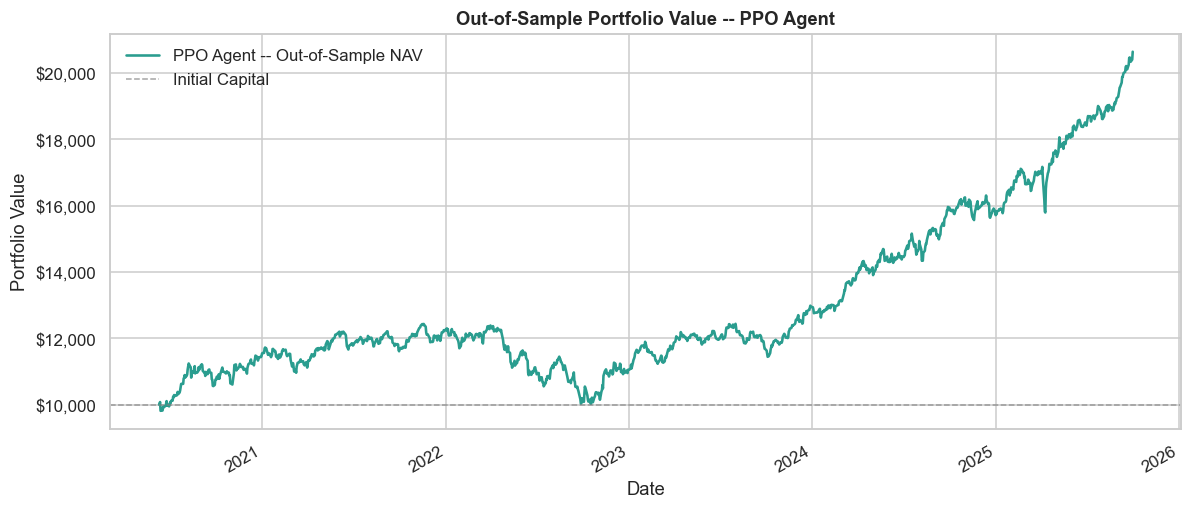

In [29]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(oos_history.index, oos_history["portfolio_value"], color="#2a9d8f", linewidth=1.7,
        label="PPO Agent -- Out-of-Sample NAV")
ax.axhline(CFG.initial_capital, color="grey", linestyle="--", linewidth=1, alpha=0.7, label="Initial Capital")
ax.set_title("Out-of-Sample Portfolio Value -- PPO Agent")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend(frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

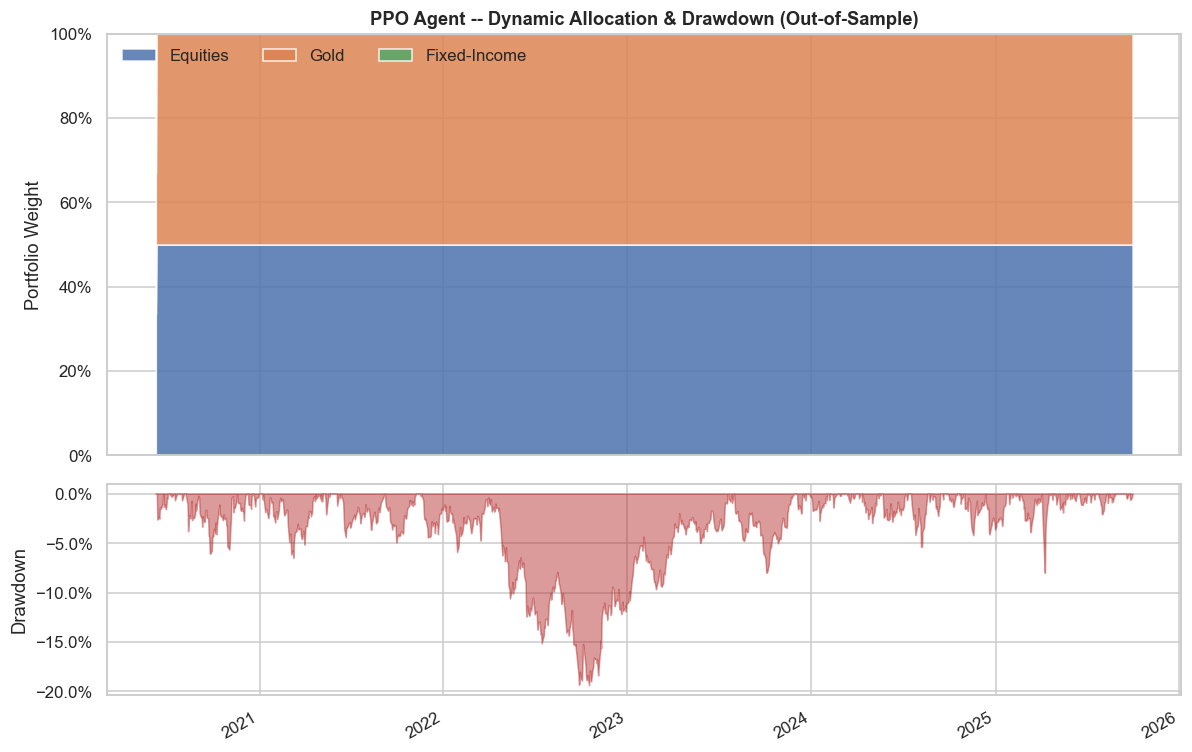

Maximum drawdown (OOS): -19.38%


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

weight_cols = [f"w_{a}" for a in CFG.assets.names]
axes[0].stackplot(
    oos_history.index, *[oos_history[c] for c in weight_cols], labels=CFG.assets.names, alpha=0.85,
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Portfolio Weight")
axes[0].set_title("PPO Agent -- Dynamic Allocation & Drawdown (Out-of-Sample)")
axes[0].legend(loc="upper left", ncol=3, frameon=False)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

nav = oos_history["portfolio_value"]
drawdown = nav / nav.cummax() - 1
axes[1].fill_between(oos_history.index, drawdown, 0, color="firebrick", alpha=0.45)
axes[1].set_ylabel("Drawdown")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Maximum drawdown (OOS): {drawdown.min():.2%}")

**Dernière Étape : COMPARAISON AVEC LA FRONTIÈRE EFFICIENTE DE MARKOWITZ**

In [31]:
def performance_summary(nav: pd.Series, periods_per_year: int = CFG.trading_days_per_year) -> Dict[str, float]:
    """Annualised return / volatility / Sharpe / max drawdown from a NAV series."""
    rets = nav.pct_change().dropna()
    ann_return = rets.mean() * periods_per_year
    ann_vol = rets.std(ddof=0) * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    max_dd = (nav / nav.cummax() - 1).min()
    return {"Ann. Return": ann_return, "Ann. Volatility": ann_vol, "Sharpe": sharpe, "Max Drawdown": max_dd}


ppo_perf = performance_summary(oos_history["portfolio_value"])

# ---------------------------------------------------------------------------- #
# Markowitz inputs (mu, Sigma) are estimated *strictly on the training window*.
# Using the full sample -- including the test period -- to build the efficient
# frontier and then comparing it to the agent's out-of-sample result would be a
# textbook look-ahead bias: both strategies must be judged on an identical,
# genuinely unseen information set.
# ---------------------------------------------------------------------------- #
mu_annual = df_train.mean() * CFG.trading_days_per_year
cov_annual = df_train.cov() * CFG.trading_days_per_year

print("PPO agent -- out-of-sample performance:")
for key, value in ppo_perf.items():
    fmt = "{:.2f}" if key == "Sharpe" else "{:.2%}"
    print(f"  {key:<16}: {fmt.format(value)}")

print("\nMean-variance inputs estimated on the training window only (no look-ahead):")
print(mu_annual.round(4).to_string())

PPO agent -- out-of-sample performance:
  Ann. Return     : 13.80%
  Ann. Volatility : 11.04%
  Sharpe          : 1.25
  Max Drawdown    : -19.38%

Mean-variance inputs estimated on the training window only (no look-ahead):
Equities       0.0395
Gold           0.0956
Fixed-Income   0.0388


On génère 10000 portefeuilles avec poids aléatoires afin de visualiser la frontière de Markowitz :

In [32]:
n_assets = len(mu_annual)
cov_matrix = cov_annual.to_numpy()
mu_vector = mu_annual.to_numpy()


def portfolio_performance(weights: np.ndarray) -> Tuple[float, float]:
    ret = float(weights @ mu_vector)
    vol = float(np.sqrt(weights @ cov_matrix @ weights))
    return ret, vol


# --- Monte Carlo cloud, purely for visualising the feasible set -----------------
rng = np.random.default_rng(CFG.seed)
n_portfolios = 10_000
mc_records = np.zeros((n_portfolios, 3))  # [volatility, return, sharpe]

for i in range(n_portfolios):
    w = rng.random(n_assets)
    w /= w.sum()
    ret, vol = portfolio_performance(w)
    mc_records[i] = [vol, ret, ret / vol]

mc_frontier = pd.DataFrame(mc_records, columns=["Volatility", "Return", "Sharpe"])


# --- Analytic optimum via constrained SLSQP -- precise, rather than relying on
#     the best of 10,000 random draws (standard practice in mean-variance work).
def neg_sharpe(weights: np.ndarray) -> float:
    ret, vol = portfolio_performance(weights)
    return -ret / vol


def volatility(weights: np.ndarray) -> float:
    return portfolio_performance(weights)[1]


bounds = tuple((0.0, 1.0) for _ in range(n_assets))
full_investment = {"type": "eq", "fun": lambda w: w.sum() - 1.0}
w0 = np.full(n_assets, 1.0 / n_assets)

msr_opt = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds, constraints=[full_investment])
mvp_opt = minimize(volatility, w0, method="SLSQP", bounds=bounds, constraints=[full_investment])

w_msr, w_mvp = msr_opt.x, mvp_opt.x
msr_ret, msr_vol = portfolio_performance(w_msr)
mvp_ret, mvp_vol = portfolio_performance(w_mvp)

weights_table = pd.DataFrame(
    {"Max-Sharpe (MSR)": w_msr, "Min-Variance (MVP)": w_mvp}, index=CFG.assets.names
)
print("In-sample optimal static weights:\n")
print(weights_table.round(3).to_string())

In-sample optimal static weights:

              Max-Sharpe (MSR)  Min-Variance (MVP)
Equities                0.0850              0.0910
Gold                    0.1310              0.0000
Fixed-Income            0.7840              0.9090


In [33]:
def static_allocation_backtest(
    weights: np.ndarray, returns: pd.DataFrame, initial_capital: float, cost_rates: np.ndarray
) -> pd.Series:
    """
    Buy-and-hold backtest of a *static* allocation, rebalanced once at inception
    (Markowitz weights are not re-optimised day-to-day, unlike the PPO agent -- the
    transaction cost is therefore charged only on the initial move into the target
    weights, from an all-cash starting position).
    """
    inception_turnover = np.abs(weights)  # moving from all-cash to target weights
    inception_cost = float(inception_turnover @ cost_rates) * initial_capital
    capital_after_cost = initial_capital - inception_cost
    daily_portfolio_returns = returns.to_numpy() @ weights
    nav = capital_after_cost * np.cumprod(1.0 + daily_portfolio_returns)
    return pd.Series(nav, index=returns.index, name="portfolio_value")


cost_vector = np.array([CFG.assets.transaction_costs[a] for a in CFG.assets.names])

msr_oos_nav = static_allocation_backtest(w_msr, df_test, CFG.initial_capital, cost_vector)
mvp_oos_nav = static_allocation_backtest(w_mvp, df_test, CFG.initial_capital, cost_vector)
equal_weight_oos_nav = static_allocation_backtest(
    np.full(n_assets, 1.0 / n_assets), df_test, CFG.initial_capital, cost_vector
)

comparison = pd.DataFrame(
    {
        "PPO Agent": ppo_perf,
        "Markowitz MSR": performance_summary(msr_oos_nav),
        "Markowitz MVP": performance_summary(mvp_oos_nav),
        "Equal-Weight (1/N)": performance_summary(equal_weight_oos_nav),
    }
).T

comparison_display = comparison.copy()
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown"]:
    comparison_display[col] = comparison_display[col].map(lambda x: f"{x:.2%}")
comparison_display["Sharpe"] = comparison_display["Sharpe"].map(lambda x: f"{x:.2f}")

print("Out-of-sample performance -- all strategies evaluated on the identical, unseen test window:\n")
print(comparison_display.to_string())

Out-of-sample performance -- all strategies evaluated on the identical, unseen test window:

                   Ann. Return Ann. Volatility Sharpe Max Drawdown
PPO Agent               13.80%          11.04%   1.25      -19.38%
Markowitz MSR            2.77%           5.98%   0.46      -23.02%
Markowitz MVP            0.72%           5.60%   0.13      -24.35%
Equal-Weight (1/N)       9.47%           8.38%   1.13      -20.00%


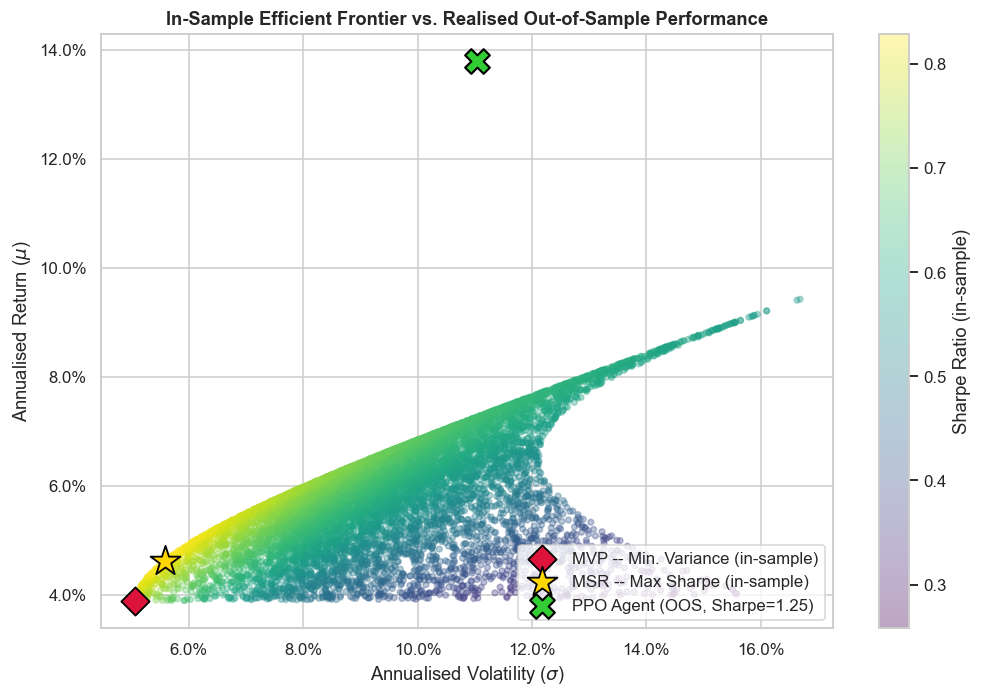


Summary -- out-of-sample results:

                   Ann. Return Ann. Volatility Sharpe Max Drawdown
PPO Agent               13.80%          11.04%   1.25      -19.38%
Markowitz MSR            2.77%           5.98%   0.46      -23.02%
Markowitz MVP            0.72%           5.60%   0.13      -24.35%
Equal-Weight (1/N)       9.47%           8.38%   1.13      -20.00%


In [34]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

scatter = ax.scatter(
    mc_frontier["Volatility"], mc_frontier["Return"], c=mc_frontier["Sharpe"],
    cmap="viridis", alpha=0.35, s=14,
)
fig.colorbar(scatter, ax=ax, label="Sharpe Ratio (in-sample)")

ax.scatter(mvp_vol, mvp_ret, marker="D", color="crimson", s=170, edgecolor="black",
           linewidth=1.2, label="MVP -- Min. Variance (in-sample)", zorder=5)
ax.scatter(msr_vol, msr_ret, marker="*", color="gold", s=420, edgecolor="black",
           linewidth=1.2, label="MSR -- Max Sharpe (in-sample)", zorder=5)

ppo_ann_vol, ppo_ann_ret = ppo_perf["Ann. Volatility"], ppo_perf["Ann. Return"]
ax.scatter(ppo_ann_vol, ppo_ann_ret, marker="X", color="limegreen", s=260, edgecolor="black",
           linewidth=1.4, label=f"PPO Agent (OOS, Sharpe={ppo_perf['Sharpe']:.2f})", zorder=6)

ax.set_title("In-Sample Efficient Frontier vs. Realised Out-of-Sample Performance")
ax.set_xlabel(r"Annualised Volatility ($\sigma$)")
ax.set_ylabel(r"Annualised Return ($\mu$)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

print("\nSummary -- out-of-sample results:\n")
print(comparison_display.to_string())

**Conclusion :**
On remarque que l'algorithme PPO a de très bonnes performances. Il surpasse de trois fois le rendement annualisé du MSR et possède un ratio de sharpe bien plus élevé que le MSR. Toutefois, il semble "prendre" plus de risques dans les choix de portefeuille mais ce risque est "justifié" par un ratio de sharpe meilleur ! 